In [23]:
import pandas as pd
import os
import json

def parse_json_stream(file_path):
    """
    Parses a file containing a stream of concatenated JSON objects.
    """
    with open(file_path, 'r') as f:
        content = f.read()
    
    decoder = json.JSONDecoder()
    objects = []
    pos = 0
    # Skip leading whitespace
    while pos < len(content) and content[pos].isspace():
        pos += 1
    
    while pos < len(content):
        try:
            obj, pos = decoder.raw_decode(content, pos)
            objects.append(obj)
            # Skip whitespace between objects
            while pos < len(content) and content[pos].isspace():
                pos += 1
        except json.JSONDecodeError:
            # Handle cases where decoding might fail, e.g., trailing characters
            break
            
    return objects

# Directory containing the JSON files
data_dir = 'infer_metrics'
all_metrics = []

# Check if the directory exists
if os.path.isdir(data_dir):
    # Iterate over each file in the directory
    for filename in os.listdir(data_dir):
        if filename.endswith('.json'):
            file_path = os.path.join(data_dir, filename)
            # Parse the stream of JSON objects from the file
            metrics_from_file = parse_json_stream(file_path)
            all_metrics.extend(metrics_from_file)

# Create a pandas DataFrame from the list of dictionaries
if all_metrics:
    df = pd.DataFrame(all_metrics)
    # Sort by experiment number for consistent ordering
    if 'experiment_num' in df.columns:
        df = df.sort_values(by='experiment_num').reset_index(drop=True)
    print(df.head())
else:
    print(f"No JSON files found or parsed in the '{data_dir}' directory.")
    # Create an empty dataframe to avoid errors in subsequent cells
    df = pd.DataFrame()

        model precision  pretrained device  batch_size  num_batches  \
0  bert-large      bf16        True   cuda        1024          100   
1  bert-large      bf16        True   cuda          96          100   
2  bert-large      bf16        True   cuda          96          100   
3  bert-large      fp16        True   cuda          64          100   
4    resnet50      bf16        True   cuda          32          100   

   warmup_batches  total_samples  total_inference_time_sec  \
0               5         102400                165.554519   
1               5           9600                  6.357300   
2               5           9600                  6.352717   
3               5           6400                  4.490463   
4               5           3200                  2.064110   

   throughput_samples_per_sec  ...  p90_latency_ms  p95_latency_ms  \
0                  618.527363  ...     1657.343650     1657.601166   
1                 1510.075135  ...       63.725519       63.

In [31]:
df.head() 
df.tail()

,model,precision,pretrained,device,batch_size,num_batches,warmup_batches,total_samples,total_inference_time_sec,throughput_samples_per_sec,...,p90_latency_ms,p95_latency_ms,p99_latency_ms,peak_memory_mb,experiment_num,gpu_peak_memory_logger_mb,gpu_avg_util_percent,gpu_avg_power_watts,avg_utilization_percent,avg_power_watts
3558,bert-large,fp16,True,cuda,96,100,5,9600,6.852578,1400.932628,...,68.673015,68.699086,68.732939,2224.036133,100,NaN,NaN,NaN,NaN,NaN
3559,resnet50,fp16,True,cuda,32,100,5,3200,1.036197,3088.215298,...,10.527253,10.533404,10.560303,277.838379,100,NaN,NaN,NaN,NaN,NaN
3560,gpt2,bf16,True,cuda,24,100,5,2400,2.400304,999.873515,...,23.720026,23.837829,25.893011,1584.767090,100,NaN,NaN,NaN,NaN,NaN
3561,bert-large,fp32,True,cuda,64,100,5,6400,7.918545,808.229264,...,79.487109,79.642630,79.788091,1639.473633,100,2683.1875,95.647059,398.140000,NaN,NaN
3562,bert-large,fp32,True,cuda,32,100,5,3200,3.680084,869.545259,...,36.963773,36.992908,37.272594,1463.426758,100,2567.7500,88.125000,277.707625,NaN,NaN


Device Performance and Efficiency Summary:
  device  mean_throughput  mean_peak_memory_mb  efficiency_throughput_per_mb
0   cuda      1928.579679           1544.02016                      1.249064


/var/folders/_b/xtqny3jn4xj460cq_85fbhn40000gn/T/ipykernel_16762/1076338899.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=device_summary, x='device', y='mean_throughput', ax=axes[0], palette='viridis')
/var/folders/_b/xtqny3jn4xj460cq_85fbhn40000gn/T/ipykernel_16762/1076338899.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=device_summary, x='device', y='mean_peak_memory_mb', ax=axes[1], palette='plasma')
/var/folders/_b/xtqny3jn4xj460cq_85fbhn40000gn/T/ipykernel_16762/1076338899.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

 

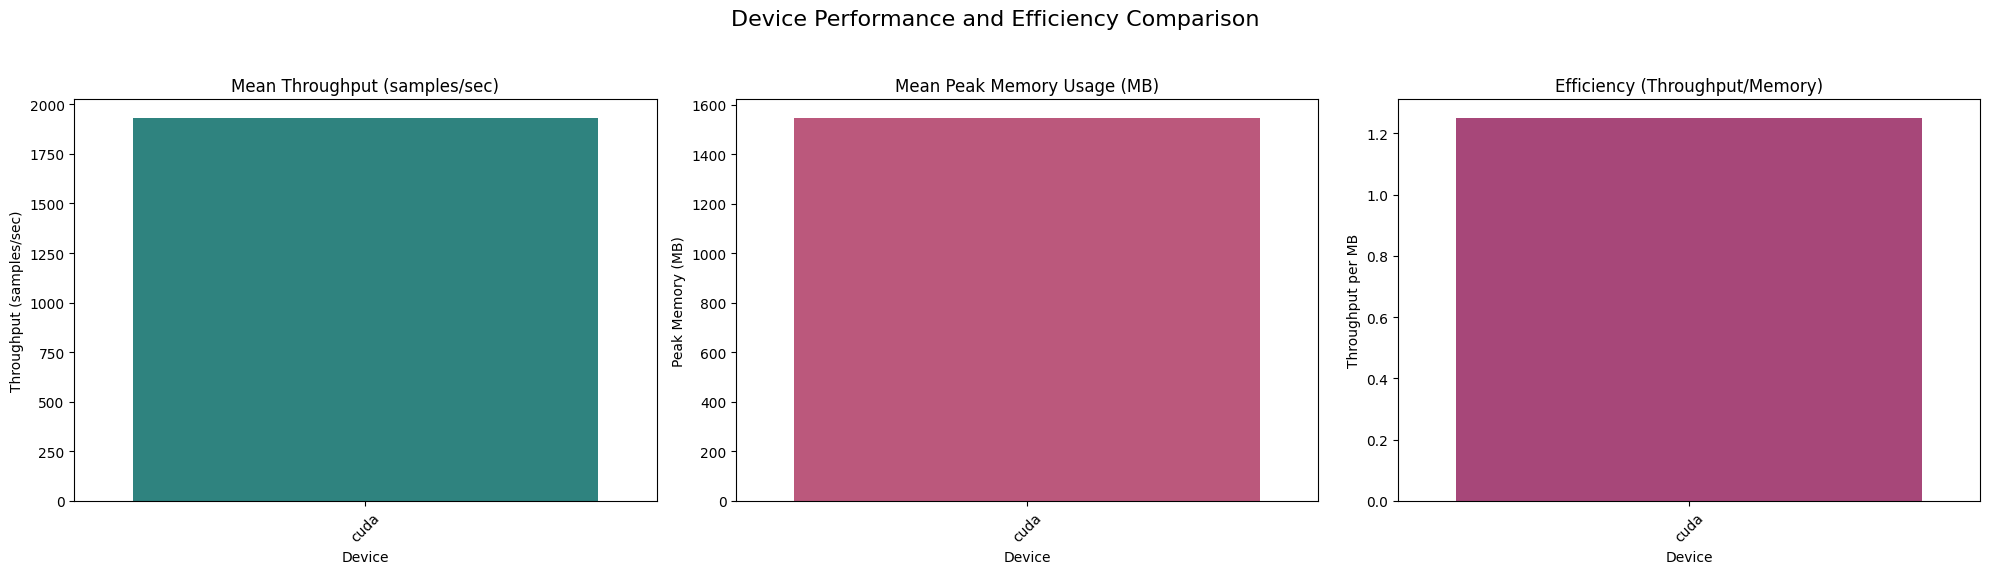

In [25]:
import seaborn as sns

import matplotlib.pyplot as plt

if not df.empty:
    # Group by device and calculate the mean for performance and memory metrics
    device_summary = df.groupby('device').agg(
        mean_throughput=('throughput_samples_per_sec', 'mean'),
        mean_peak_memory_mb=('peak_memory_mb', 'mean')
    ).reset_index()

    # Calculate an efficiency score: throughput per megabyte of peak memory
    device_summary['efficiency_throughput_per_mb'] = device_summary['mean_throughput'] / device_summary['mean_peak_memory_mb']

    # Sort by mean throughput for clearer visualization
    device_summary = device_summary.sort_values(by='mean_throughput', ascending=False)

    print("Device Performance and Efficiency Summary:")
    print(device_summary)

    # Create subplots for visualization
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle('Device Performance and Efficiency Comparison', fontsize=16)

    # Plot Mean Throughput
    sns.barplot(data=device_summary, x='device', y='mean_throughput', ax=axes[0], palette='viridis')
    axes[0].set_title('Mean Throughput (samples/sec)')
    axes[0].set_ylabel('Throughput (samples/sec)')
    axes[0].set_xlabel('Device')
    axes[0].tick_params(axis='x', rotation=45)

    # Plot Mean Peak Memory
    sns.barplot(data=device_summary, x='device', y='mean_peak_memory_mb', ax=axes[1], palette='plasma')
    axes[1].set_title('Mean Peak Memory Usage (MB)')
    axes[1].set_ylabel('Peak Memory (MB)')
    axes[1].set_xlabel('Device')
    axes[1].tick_params(axis='x', rotation=45)

    # Plot Efficiency
    sns.barplot(data=device_summary, x='device', y='efficiency_throughput_per_mb', ax=axes[2], palette='magma')
    axes[2].set_title('Efficiency (Throughput/Memory)')
    axes[2].set_ylabel('Throughput per MB')
    axes[2].set_xlabel('Device')
    axes[2].tick_params(axis='x', rotation=45)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
else:
    print("DataFrame is empty. No comparison can be made.")